# LSA - News Classification

Project 1 - Linear Algebra (Spring 1403) - Dr. Sarafraz

ECE - University of Tehran

Designed by:
[Erfan Asgari](https://github.com/erfanasgari21),
[Fardin Abbasi](https://github.com/fardinabbasi)

In [1]:
!pip install kaggle



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## Download the Dataset

In [2]:
import os
os.environ['KAGGLE_USERNAME'] = ''
os.environ['KAGGLE_KEY'] = ''
!kaggle datasets download -d tanishqdublish/text-classification-documentation

Dataset URL: https://www.kaggle.com/datasets/tanishqdublish/text-classification-documentation
License(s): apache-2.0
text-classification-documentation.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
import zipfile
import os
if os.path.exists('text-classification-documentation.zip'):
    with zipfile.ZipFile('text-classification-documentation.zip', 'r') as zip_ref:
        zip_ref.extractall('text_classification')
    print('Dataset extracted successfully.')
else:
    print('Zip file not found. Skipping extraction since local dataset exists.')


Dataset extracted successfully.


In [4]:
import pandas as pd
import os
if os.path.exists('dataset/df_file.csv'):
    file_path = 'dataset/df_file.csv'
elif os.path.exists('text_classification/df_file.csv'):
    file_path = 'text_classification/df_file.csv'
else:
    file_path = 'df_file.csv'
df = pd.read_csv(file_path)
print('Dataset loaded successfully, shape:', df.shape)


Dataset loaded successfully, shape: (2225, 2)


In [5]:
import re

# Function to cleanse text
def cleanse_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and unwanted characters (including newline characters)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\n', ' ', text)  # Replace newline characters with space
    text = re.sub(r'\s+', ' ', text)  # Replace multiple spaces with a single space
    text = text.strip()  # Remove leading and trailing spaces
    return text

df['Text'] = df['Text'].apply(cleanse_text)

## Visualization

### Table Summary

In [6]:
df.head()

,Text,Label
0,budget to set scene for election gordon brown ...,0
1,army chiefs in regiments decision military chi...,0
2,howard denies split over id cards michael howa...,0
3,observers to monitor uk election ministers wil...,0
4,kilroy names election seat target exchat show ...,0


### Labels Frequency

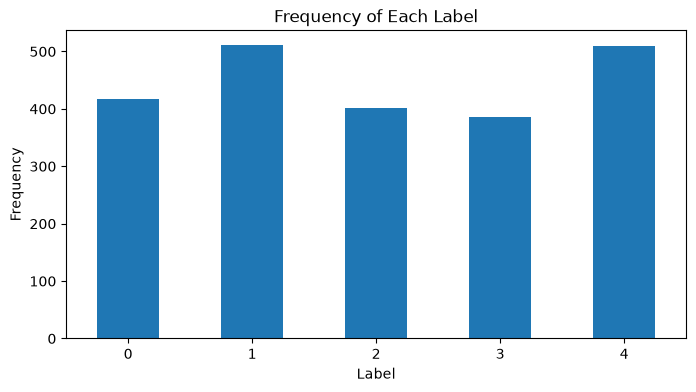

In [7]:
import matplotlib.pyplot as plt

label_frequency = df['Label'].value_counts()

plt.figure(figsize=(8, 4))
label_frequency.sort_index().plot(kind='bar')
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.title('Frequency of Each Label')
plt.xticks(rotation=0)
plt.show()


### Word Cloud

In [8]:
!pip install wordcloud

  Obtaining dependency information for wordcloud from https://files.pythonhosted.org/packages/04/72/1aeb291fd5965826e478b0efd8bcb4351e8a2434f366416537096cd41a0d/wordcloud-1.9.6-cp312-cp312-macosx_11_0_arm64.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.9/168.9 kB 959.2 kB/s eta 0:00:001m664.8 kB/s eta 0:00:01

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


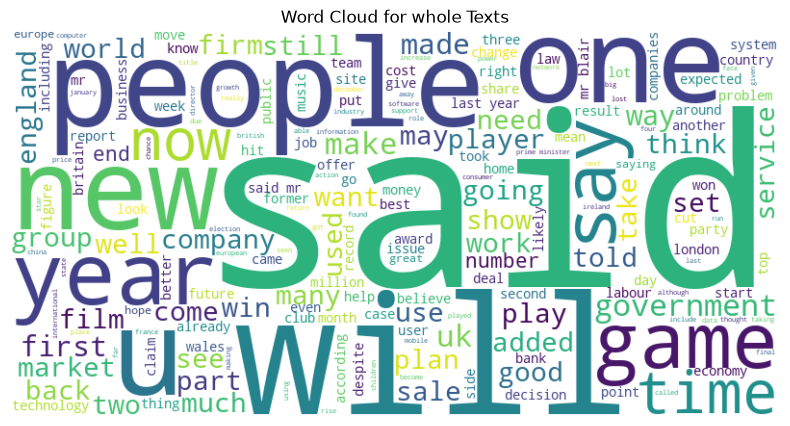

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt


def generate_word_cloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title)
    plt.axis('off')
    plt.show()

text = " ".join(df['Text'])
generate_word_cloud(text, f'Word Cloud for whole Texts')

> How to read word clouds:
each word font size is multiplied by its frequency in the underlyin text.
Word selection typically doesnt use stopwords first
colors are usually just for showing and vizualize and dont have special meaning.
Word clouds are good for a quick look at
dominant themes and words.

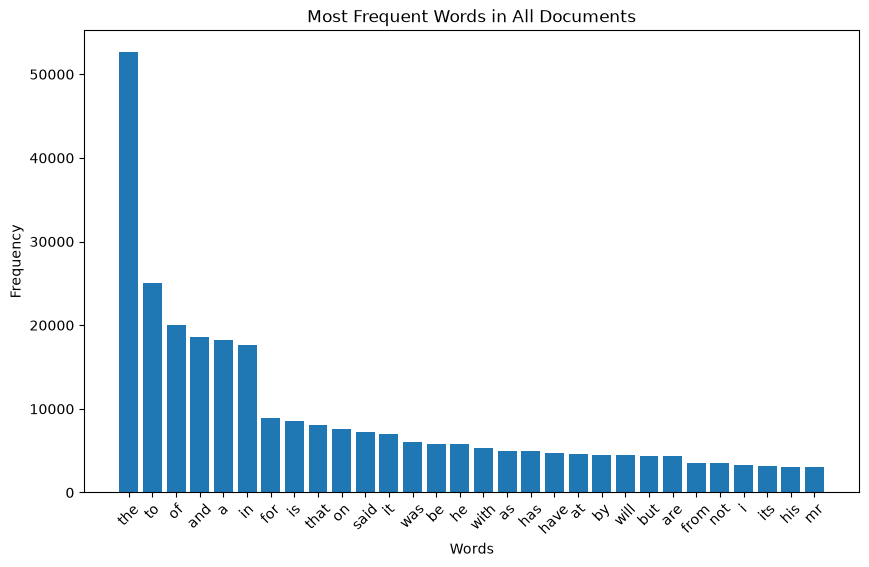

In [10]:
import matplotlib.pyplot as plt
from collections import Counter
import string
import re


all_text = " ".join(df['Text'])

all_text = all_text.lower()  # Convert to lowercase
all_text = re.sub(f"[{string.punctuation}]", " ", all_text)  # Remove punctuation
words = all_text.split()

word_counts = Counter(words)

most_common_words = word_counts.most_common(30)  # Adjust the number to show more or fewer words

words, counts = zip(*most_common_words)

plt.figure(figsize=(10, 6))
plt.bar(words, counts)
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.title('Most Frequent Words in All Documents')
plt.xticks(rotation=45)
plt.show()


> the 30 most frequent words are almost all generic ("the", "said", "year", "also", "mr") words that can show up in every topic.
Raw frequency alone does not tell us what a document is about.
This is exactly the TF vs. TF-IDF problem from Q1: to find topic
signal we need words that are frequent in a document but not frequent
everywhere, which is why the words.csv vocabulary matters more than raw counts.

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
documents = df['Text'].str.lower().str.replace(f"[{string.punctuation}]", " ", regex=True)

# Vectorize the text data using the bag-of-words model and apply TF-IDF
vectorizer = TfidfVectorizer(stop_words='english', max_features=150)
X = vectorizer.fit_transform(documents)

# Get feature names (words)
feature_names = vectorizer.get_feature_names_out()
print("Top 100 important words:")
print(feature_names)

Top 100 important words:
['10' '2003' '2004' '2005' 'according' 'action' 'added' 'bank' 'bbc'
 'best' 'better' 'big' 'blair' 'britain' 'british' 'brown' 'business'
 'came' 'campaign' 'chief' 'club' 'come' 'companies' 'company' 'country'
 'court' 'data' 'day' 'deal' 'decision' 'despite' 'did' 'digital'
 'director' 'dont' 'economic' 'economy' 'election' 'end' 'england'
 'europe' 'european' 'expected' 'far' 'figures' 'film' 'final' 'firm'
 'firms' 'future' 'game' 'games' 'general' 'going' 'good' 'got'
 'government' 'great' 'group' 'growth' 'help' 'high' 'hit' 'home' 'howard'
 'im' 'including' 'industry' 'information' 'international' 'just' 'know'
 'labour' 'law' 'life' 'like' 'likely' 'london' 'make' 'market' 'media'
 'million' 'minister' 'mobile' 'money' 'month' 'months' 'mr' 'music'
 'need' 'net' 'new' 'news' 'number' 'office' 'online' 'open' 'party'
 'people' 'phone' 'place' 'plans' 'play' 'players' 'prime' 'public'
 'radio' 'real' 'really' 'record' 'report' 'right' 'said' 'sales' 'say

In [12]:
important_words = pd.read_csv("words.csv").squeeze().tolist()

## Bag of Words

In [13]:
import pandas as pd

def count_words(text):
    word_count = {word: 0 for word in important_words}
    for word in text.split():
        if word in word_count:
            word_count[word] += 1
    return word_count

df['Word_Counts'] = df['Text'].apply(count_words)
word_counts_df_all = pd.DataFrame(df['Word_Counts'].tolist(), index=df.index)

# Split training and test data (Q10 Note: 2000 train, 225 test)
df_train = df.iloc[:2000].reset_index(drop=True)
df_test = df.iloc[2000:].reset_index(drop=True)

word_counts_df = word_counts_df_all.iloc[:2000].reset_index(drop=True)
word_counts_df_test = word_counts_df_all.iloc[2000:].reset_index(drop=True)

print('Training BoW matrix shape:', word_counts_df.shape)
print('Test BoW matrix shape:', word_counts_df_test.shape)
word_counts_df


Training BoW matrix shape: (2000, 52)
Test BoW matrix shape: (225, 52)


,artist,chief,china,club,company,computer,country,deal,digital,director,...,sale,service,tax,technology,time,uk,user,win,won,work
0,0,1,0,0,0,0,0,0,0,0,...,0,0,6,0,2,1,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,3,0,0,0,1
4,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,3,0,0,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,0,1,0,0,2,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1996,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
1997,0,2,0,0,1,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [14]:
word_counts_df.describe()

,artist,chief,china,club,company,computer,country,deal,digital,director,...,sale,service,tax,technology,time,uk,user,win,won,work
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.026500,0.168500,0.079500,0.152000,0.229500,0.156000,0.172500,0.180000,0.207000,0.199000,...,0.096500,0.214500,0.181000,0.269000,0.544500,0.446000,0.026500,0.302500,0.261500,0.285000
std,0.220957,0.499232,0.659088,0.788167,0.696471,0.710575,0.611499,0.691259,0.989263,0.701887,...,0.469359,0.838356,1.075554,1.054607,1.031286,1.112521,0.220957,0.863925,0.804637,0.766204
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,5.000000,7.000000,13.000000,12.000000,7.000000,8.000000,8.000000,8.000000,17.000000,19.000000,...,7.000000,13.000000,14.000000,12.000000,20.000000,12.000000,4.000000,13.000000,12.000000,15.000000


## Standardization

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
word_counts_scaled = scaler.fit_transform(word_counts_df)

## Truncated SVD

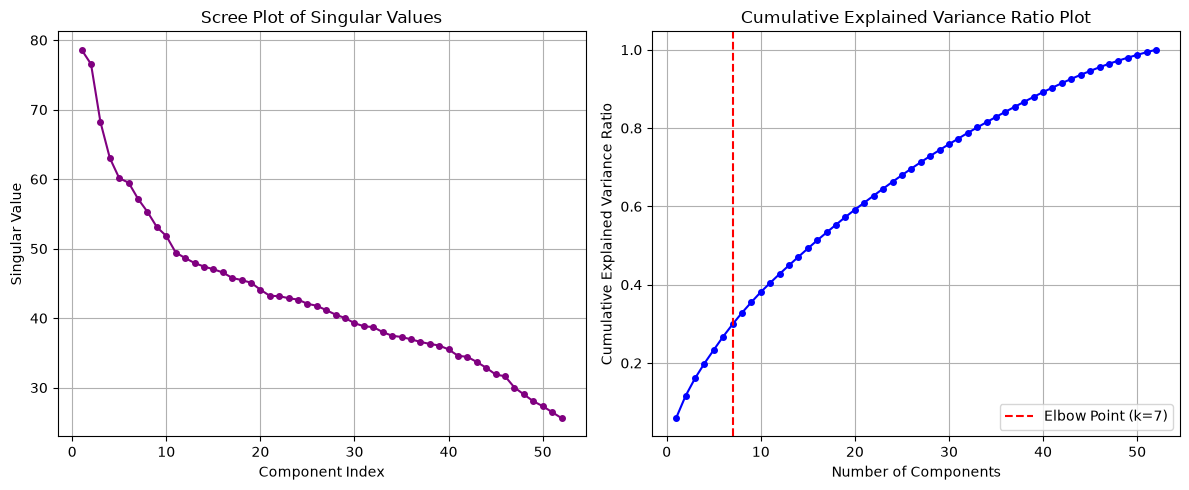

Truncated SVD details:
  Selected rank (k): 7
  Absolute reconstruction error (Frobenius Norm): 270.0174
  Relative reconstruction error: 0.8373


In [16]:
from sklearn.decomposition import TruncatedSVD
import numpy as np
import matplotlib.pyplot as plt

# Compute full SVD using numpy to get all singular values and cumulative variance
U_full, S_full, Vt_full = np.linalg.svd(word_counts_scaled, full_matrices=False)

total_variance = np.sum(S_full**2)
explained_variance_ratio = (S_full**2) / total_variance
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Plot singular values and cumulative variance
plt.figure(figsize=(12, 5))

# Scree Plot
plt.subplot(1, 2, 1)
plt.plot(range(1, len(S_full) + 1), S_full, 'o-', color='purple', markersize=4)
plt.xlabel('Component Index')
plt.ylabel('Singular Value')
plt.title('Scree Plot of Singular Values')
plt.grid(True)

# Cumulative explained variance
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance_ratio) + 1), cumulative_variance_ratio, 'o-', color='blue', markersize=4)
plt.axvline(x=7, color='red', linestyle='--', label='Elbow Point (k=7)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.title('Cumulative Explained Variance Ratio Plot')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Based on the elbow point (around k=7), we perform Truncated SVD with k = 7
n_components = 7
svd = TruncatedSVD(n_components=n_components)
lsi_matrix = svd.fit_transform(word_counts_scaled)

# Calculate reconstruction error using Frobenius norm
U_k = U_full[:, :n_components]
S_k = np.diag(S_full[:n_components])
Vt_k = Vt_full[:n_components, :]
X_reconstructed = U_k @ S_k @ Vt_k
reconstruction_error_abs = np.linalg.norm(word_counts_scaled - X_reconstructed, 'fro')
reconstruction_error_rel = reconstruction_error_abs / np.linalg.norm(word_counts_scaled, 'fro')

print('Truncated SVD details:')
print(f'  Selected rank (k): {n_components}')
print(f'  Absolute reconstruction error (Frobenius Norm): {reconstruction_error_abs:.4f}')
print(f'  Relative reconstruction error: {reconstruction_error_rel:.4f}')


## Randomized SVD Implementation (Q13 & Q14)

We implement Randomized SVD from scratch using the algorithm described in the documentation. We will then compare its reconstruction error with that of Truncated SVD.

In [17]:
import numpy as np

def randomized_svd(A, rank, n_iter=5):
    m, n = A.shape
    # Step 1: Generate a random Gaussian projection matrix
    omega = np.random.randn(n, rank)
    
    # Step 2: Form a sample matrix Y = A * omega
    Y = A @ omega
    
    # Power iterations to improve singular vector accuracy
    for _ in range(n_iter):
        Y = A @ (A.T @ Y)
        
    # Step 3: Orthonormalize Y using QR decomposition to find an orthonormal basis Q
    Q, _ = np.linalg.qr(Y)
    
    # Step 4: Project A onto the low-dimensional subspace: B = Q.T @ A
    B = Q.T @ A
    
    # Step 5: Compute SVD on the smaller matrix B
    Ub, S, Vt = np.linalg.svd(B, full_matrices=False)
    
    # Step 6: Reconstruct the left singular vectors of A
    U = Q @ Ub
    
    return U, S, Vt


In [18]:
# Run Randomized SVD on the scaled training BoW matrix
U_rand, S_rand, Vt_rand = randomized_svd(word_counts_scaled, n_components)

# Calculate reconstruction error for Randomized SVD
X_reconstructed_rand = U_rand @ np.diag(S_rand) @ Vt_rand
reconstruction_error_rand_abs = np.linalg.norm(word_counts_scaled - X_reconstructed_rand, 'fro')
reconstruction_error_rand_rel = reconstruction_error_rand_abs / np.linalg.norm(word_counts_scaled, 'fro')

print(f"Randomized SVD with rank k = {n_components}:")
print(f"  Absolute reconstruction error: {reconstruction_error_rand_abs:.4f}")
print(f"  Relative reconstruction error: {reconstruction_error_rand_rel:.4f}")

print(f"\nReconstruction Error Comparison (k = {n_components}):")
print(f"  Truncated SVD:  {reconstruction_error_rel:.4f}")
print(f"  Randomized SVD: {reconstruction_error_rand_rel:.4f}")


Randomized SVD with rank k = 7:
  Absolute reconstruction error: 272.7392
  Relative reconstruction error: 0.8457

Reconstruction Error Comparison (k = 7):
  Truncated SVD:  0.8373
  Randomized SVD: 0.8457


## Visualize Word Embeddings

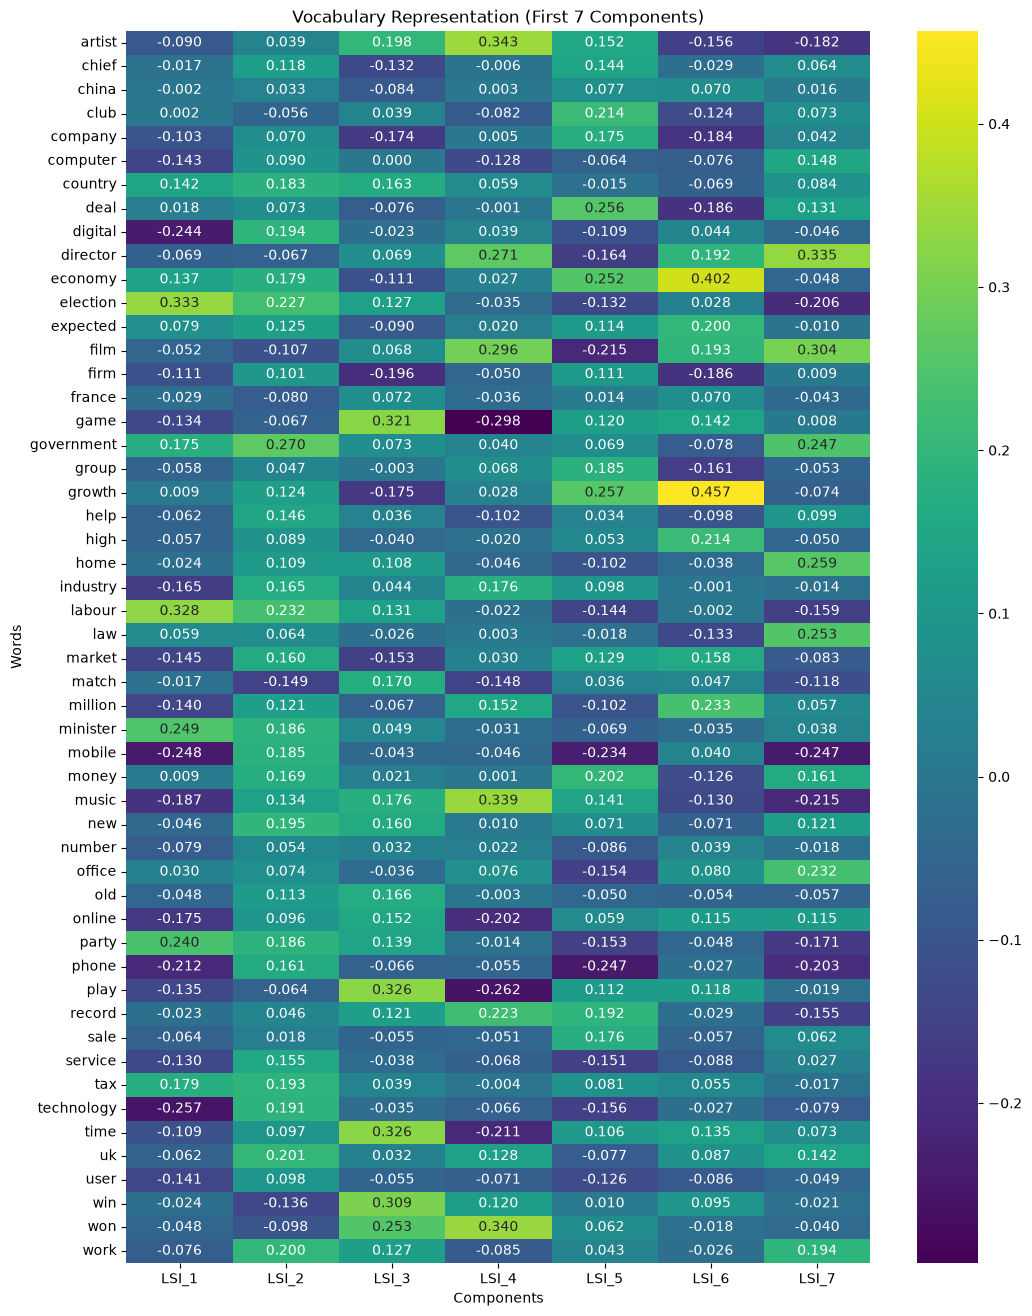

In [19]:
import seaborn as sns

# Convert the LSI matrix to a DataFrame for easier interpretation
lsi_df = pd.DataFrame(lsi_matrix, columns=[f'LSI_{i+1}' for i in range(n_components)])

def plot_heatmap(data, title):
    plt.figure(figsize=(12, 16))
    sns.heatmap(data, annot=True, cmap='viridis', fmt='.3f')
    plt.title(title)
    plt.xlabel('Components')
    plt.ylabel('Words')
    plt.show()

vocab_representation = svd.components_.T  # Shape: (num_words, n_components)

vocab_df_7 = pd.DataFrame(vocab_representation[:, :n_components], index=important_words, columns=[f'LSI_{i+1}' for i in range(n_components)])

plot_heatmap(vocab_df_7, f'Vocabulary Representation (First {n_components} Components)')


## Intuition of each component (concept)

In [20]:
# Find the 5 words with the strongest values for each component
top_words = {}
for i in range(n_components):
    component_loadings = vocab_representation[:, i]
    top_indices = abs(component_loadings).argsort()[-5:][::-1]  # Get indices of top 10 values
    top_words[f'Component_{i+1}'] = [(important_words[idx], component_loadings[idx]) for idx in top_indices]

# Print the top 10 words and their values for each component
for component, words in top_words.items():
    print(f"{component}:")
    for word, value in words:
        print(f"  {word}: {value:.4f}")


Component_1:
  election: 0.3331
  labour: 0.3281
  technology: -0.2569
  minister: 0.2486
  mobile: -0.2478
Component_2:
  government: 0.2699
  labour: 0.2317
  election: 0.2273
  uk: 0.2015
  work: 0.1999
Component_3:
  play: 0.3264
  time: 0.3261
  game: 0.3214
  win: 0.3088
  won: 0.2533
Component_4:
  artist: 0.3426
  won: 0.3397
  music: 0.3391
  game: -0.2980
  film: 0.2959
Component_5:
  growth: 0.2566
  deal: 0.2558
  economy: 0.2520
  phone: -0.2470
  mobile: -0.2340
Component_6:
  growth: 0.4569
  economy: 0.4020
  million: 0.2332
  high: 0.2143
  expected: 0.2000
Component_7:
  director: 0.3355
  film: 0.3035
  home: 0.2590
  law: 0.2529
  mobile: -0.2473


## Labels in terms of concepts

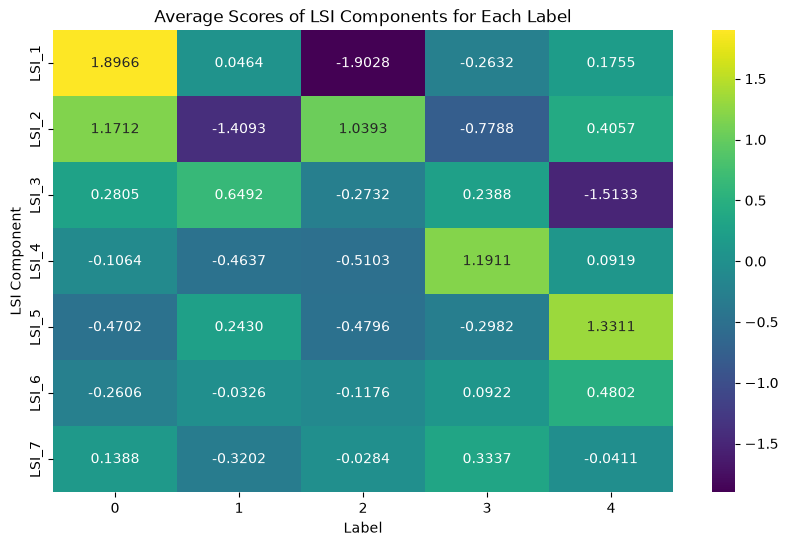

In [21]:
# Add the labels to the LSI DataFrame
lsi_df['Label'] = df_train['Label']

# Group by the label and calculate the average score of each component for each label
avg_scores = lsi_df.groupby('Label').mean()

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(avg_scores.T, annot=True, cmap='viridis', fmt='.4f')
plt.title('Average Scores of LSI Components for Each Label')
plt.xlabel('Label')
plt.ylabel('LSI Component')
plt.show()


# Querying
To find the most relevant documents to a single word.

In [22]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def find_relevant_documents(word, df, important_words):
    if word not in important_words:
        print(f"The word '{word}' is not in the vocabulary.")
        return None
    
    word_index = important_words.index(word)
    word_representation = svd.components_.T[word_index]
    
    cosine_similarities = cosine_similarity([word_representation], df)
    cosine_similarities = cosine_similarities.flatten()
    
    result_df = pd.DataFrame({'Document_Index': df.index, 'Cosine_Similarity': cosine_similarities})
    result_df = result_df.sort_values(by='Cosine_Similarity', ascending=False)
    relevant_indices = result_df['Document_Index'].tolist()
    
    return relevant_indices, cosine_similarities

word = 'game'
relevant_indices, _ = find_relevant_documents(word, lsi_df.drop(columns=['Label']), important_words)

relevant_texts = df_train.loc[relevant_indices[:10]]
relevant_texts


,Text,Label,Word_Counts
1086,blinx sequel purrs nicely the original blinx w...,2,"{'artist': 0, 'chief': 0, 'china': 0, 'club': ..."
956,no half measures with halflife 2 could halflif...,2,"{'artist': 0, 'chief': 0, 'china': 0, 'club': ..."
1094,ban hits halflife 2 pirates hard about 20000 p...,2,"{'artist': 0, 'chief': 0, 'china': 0, 'club': ..."
695,moody joins up with england lewis moody has fl...,1,"{'artist': 0, 'chief': 0, 'china': 0, 'club': ..."
1232,gritty return for prince of persia still baski...,2,"{'artist': 0, 'chief': 0, 'china': 0, 'club': ..."
1108,online games play with politics after bubbling...,2,"{'artist': 0, 'chief': 0, 'china': 0, 'club': ..."
945,halo fans hope for sequel xbox video game halo...,2,"{'artist': 0, 'chief': 1, 'china': 0, 'club': ..."
606,real will finish abandoned match real madrid a...,1,"{'artist': 0, 'chief': 0, 'china': 0, 'club': ..."
663,desailly backs blues revenge trip marcel desai...,1,"{'artist': 0, 'chief': 0, 'china': 0, 'club': ..."
854,desailly backs blues revenge trip marcel desai...,1,"{'artist': 0, 'chief': 0, 'china': 0, 'club': ..."


## Similarity between words and labels

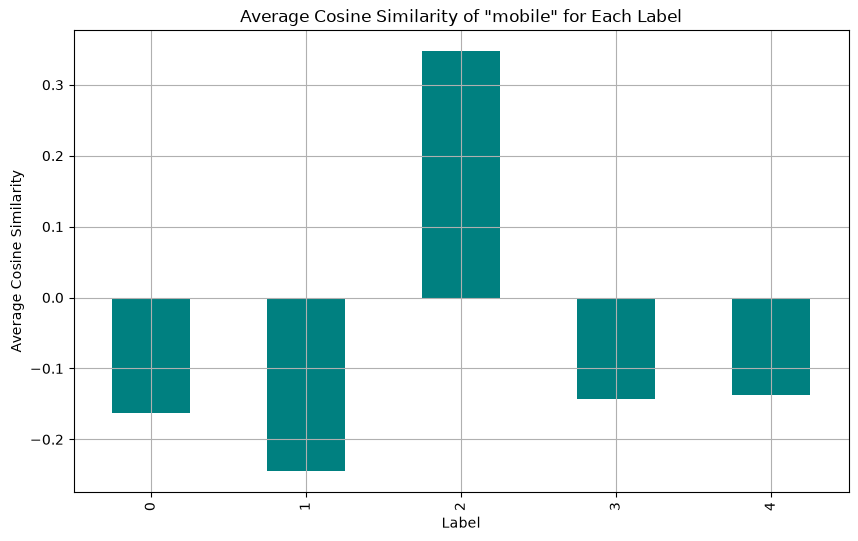

In [23]:
word = 'mobile'
relevant_indices, cosine_similarities = find_relevant_documents(word, lsi_df.drop(columns=['Label']), important_words)

df_train['Cosine_Similarity'] = cosine_similarities

average_cosine_similarity_per_label = df_train.groupby('Label')['Cosine_Similarity'].mean()

plt.figure(figsize=(10, 6))
average_cosine_similarity_per_label.plot(kind='bar', color='teal')
plt.title(f'Average Cosine Similarity of "{word}" for Each Label')
plt.xlabel('Label')
plt.ylabel('Average Cosine Similarity')
plt.grid(True)
plt.show()


## Similarity between documents and words

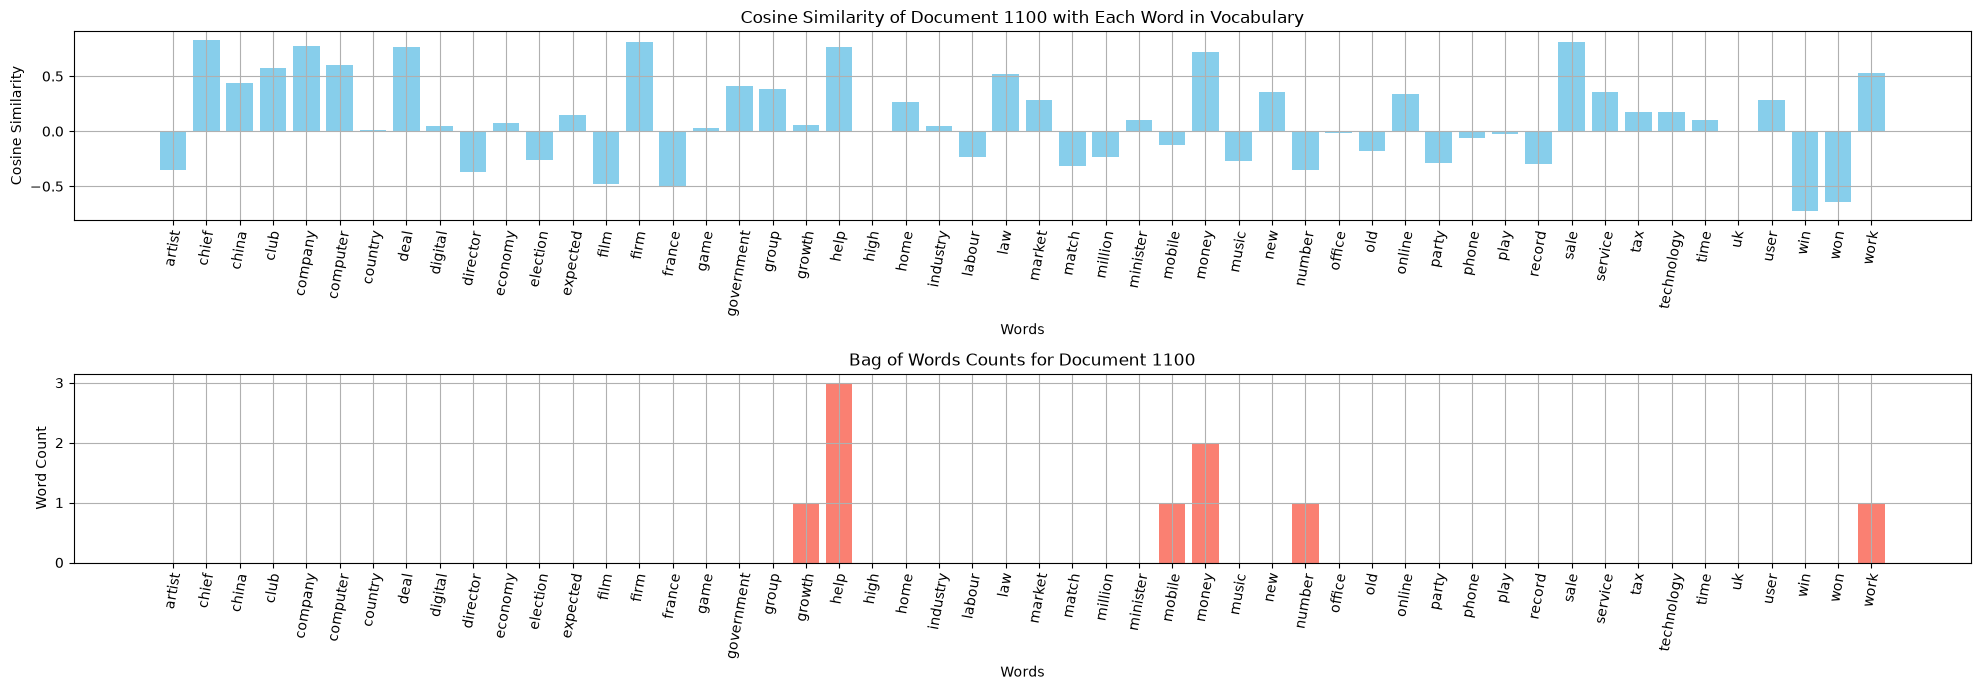

In [24]:
import matplotlib.pyplot as plt

def document_similarity_with_words(doc_index, df, important_words):
    doc_representation = lsi_matrix[doc_index]
    
    # Calculate cosine similarity between the document representation and each word representation
    word_similarities = {}
    for word in important_words:
        word_index = important_words.index(word)
        word_representation = svd.components_.T[word_index]
        similarity = cosine_similarity([doc_representation], [word_representation])[0][0]
        word_similarities[word] = similarity
        
    return word_similarities

doc_index = 1100
similarities = document_similarity_with_words(doc_index, lsi_df.drop(columns=['Label']), important_words)

words = list(similarities.keys())
cosine_sim_values = list(similarities.values())
word_counts = df_train['Word_Counts'].iloc[doc_index]

plt.figure(figsize=(20, 7))

plt.subplot(2, 1, 1)
plt.bar(words, cosine_sim_values, color='skyblue')
plt.xlabel('Words')
plt.ylabel('Cosine Similarity')
plt.title(f'Cosine Similarity of Document {doc_index} with Each Word in Vocabulary')
plt.xticks(rotation=80)
plt.grid(True)

plt.subplot(2, 1, 2)
plt.bar(word_counts.keys(), word_counts.values(), color='salmon')
plt.xlabel('Words')
plt.ylabel('Word Count')
plt.title(f'Bag of Words Counts for Document {doc_index}')
plt.xticks(rotation=80)
plt.grid(True)

plt.tight_layout()
plt.show()


## Classification

In [25]:
from sklearn.metrics.pairwise import cosine_similarity

def label_alignment_scores(document_latent_vector, lsi_df):
    # Calculate cosine similarity between the document's latent vector and each label's average concept vector
    label_scores = {}
    for label in lsi_df['Label'].unique():
        label_documents = lsi_df[lsi_df['Label'] == label].drop(columns=['Label'])
        average_latent_vector = label_documents.mean(axis=0)
        similarity_score = cosine_similarity([document_latent_vector], [average_latent_vector])[0][0]
        label_scores[label] = similarity_score
    return label_scores

document_latent_vector = lsi_matrix[1280]
alignment_scores = label_alignment_scores(document_latent_vector, lsi_df)

print('Alignment Scores:')
for label, score in alignment_scores.items():
    print(f'Label {label}: {score}')


Alignment Scores:
Label 0: -0.3278947110300887
Label 1: -0.3935400031256891
Label 2: 0.9519910968428231
Label 3: -0.2292049082369499
Label 4: -0.1469362024967293


In [26]:
predicted_labels = []

for i, document_latent_vector in enumerate(lsi_matrix):
    alignment_scores = label_alignment_scores(document_latent_vector, lsi_df)
    predicted_label = max(alignment_scores, key=alignment_scores.get)
    predicted_labels.append(predicted_label)

predicted_labels = pd.Series(predicted_labels)
accuracy = (predicted_labels == lsi_df['Label']).mean()
print('Training Set Accuracy:', accuracy)


Training Set Accuracy: 0.758


## Test Set Evaluation (Q20)

We evaluate the proposed labeling and classification method on the set-aside test data (the remaining 225 rows).

In [27]:
# Standardize the test data using the scaler fitted on the training data
word_counts_scaled_test = scaler.transform(word_counts_df_test)

# Project the test data into the LSI latent space using the components matrix from Truncated SVD
lsi_matrix_test = word_counts_scaled_test @ svd.components_.T  # Shape: (225, k)
lsi_df_test = pd.DataFrame(lsi_matrix_test, columns=[f'LSI_{i+1}' for i in range(n_components)])
lsi_df_test['Label'] = df_test['Label']

# Predict labels for the test set documents using alignment scores
test_predicted_labels = []
for doc_vec in lsi_matrix_test:
    scores = label_alignment_scores(doc_vec, lsi_df)
    pred_label = max(scores, key=scores.get)
    test_predicted_labels.append(pred_label)

test_predicted_labels = pd.Series(test_predicted_labels)
test_accuracy = (test_predicted_labels == df_test['Label']).mean()

print('Test Set Overall Accuracy:', test_accuracy)

# Report classification accuracy for each category separately
print('\nAccuracy by category on the test set:')
for label in sorted(lsi_df['Label'].unique()):
    mask = df_test['Label'] == label
    if mask.sum() > 0:
        class_acc = (test_predicted_labels[mask] == df_test['Label'][mask]).mean()
        print(f"  Category {label} (Business): {class_acc:.4f}")
    else:
        print(f"  Category {label}: N/A (no samples in test set)")


Test Set Overall Accuracy: 0.8444444444444444

Accuracy by category on the test set:
  Category 0: N/A (no samples in test set)
  Category 1: N/A (no samples in test set)
  Category 2: N/A (no samples in test set)
  Category 3: N/A (no samples in test set)
  Category 4 (Business): 0.8444


In [28]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances

def word_similarity(word1, word2, df, important_words):
    if word1 not in important_words or word2 not in important_words:
        return None
    word1_index = important_words.index(word1)
    word2_index = important_words.index(word2)
    
    word1_representation = svd.components_.T[word1_index]
    word2_representation = svd.components_.T[word2_index]
    
    cosine_sim = cosine_similarity([word1_representation], [word2_representation])[0][0]
    euclidean_dist = euclidean_distances([word1_representation], [word2_representation])[0][0]
    
    return {'cosine_similarity': cosine_sim, 'euclidean_distance': euclidean_dist}

word_pairs = [
    ('mobile', 'technology'),
    ('director', 'film'),
    ('win', 'won'),
    ('play', 'game'),
    ('play', 'law'),
    ('government', 'music')
]

print('Word Similarity Evaluations in the Latent Space:')
print('='*60)
for w1, w2 in word_pairs:
    sims = word_similarity(w1, w2, lsi_df, important_words)
    print(f'({w1}, {w2}):')
    print(f"  Cosine Similarity:  {sims['cosine_similarity']:.4f}")
    print(f"  Euclidean Distance: {sims['euclidean_distance']:.4f}")


Word Similarity Evaluations in the Latent Space:
(mobile, technology):
  Cosine Similarity:  0.9114
  Euclidean Distance: 0.1988
(director, film):
  Cosine Similarity:  0.9894
  Euclidean Distance: 0.0781
(win, won):
  Cosine Similarity:  0.8057
  Euclidean Distance: 0.2634
(play, game):
  Cosine Similarity:  0.9955
  Euclidean Distance: 0.0528
(play, law):
  Cosine Similarity:  -0.3095
  Euclidean Distance: 0.6344
(government, music):
  Cosine Similarity:  -0.0133
  Euclidean Distance: 0.6855
